In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

In [2]:
import tensorflow as tf
from tensorflow import keras

2026-04-27 06:54:47.733588: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
train_dir = "../datafiles/cats_and_dogs_small/train"
validation_dir = "../datafiles/cats_and_dogs_small/validation"
test_dir = "../datafiles/cats_and_dogs_small/test"

## Data Preprocessing
- Read all picture files.
- Decode the JPEG content to RGB grids of pixels.
- Convert these into floating point tensors.
- Rescale the pixel values (between 0 and 255) to the [0, 1] interval.

In [4]:
# Generating batches of tensor image data with real-time data augmentation. The data will be looped over (in batches) indefinitely.
train_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255)
validation_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255)

train_generator = keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=20,
    image_size=(150, 150),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

validation_generator = keras.utils.image_dataset_from_directory(
    validation_dir,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=20,
    image_size=(150, 150),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


2026-04-27 06:55:03.975932: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Link: https://keras.io/preprocessing/image/

In [5]:
import keras
from keras import layers, models

In [6]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation="relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 17, 17, 128)      0

In [8]:
from keras import optimizers

model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=["accuracy"],
)

In [9]:
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=50
)


Epoch 1/20
100/100 [==============================] - 103s 1s/step - loss: 2.0824 - accuracy: 0.5430 - val_loss: 0.6793 - val_accuracy: 0.6050
Epoch 2/20
100/100 [==============================] - 91s 907ms/step - loss: 0.6255 - accuracy: 0.6600 - val_loss: 0.6596 - val_accuracy: 0.6480
Epoch 3/20
100/100 [==============================] - 105s 1s/step - loss: 0.4700 - accuracy: 0.7765 - val_loss: 0.7139 - val_accuracy: 0.6490
Epoch 4/20
 88/100 [=========================>....] - ETA: 8s - loss: 0.3539 - accuracy: 0.8426

KeyboardInterrupt: 

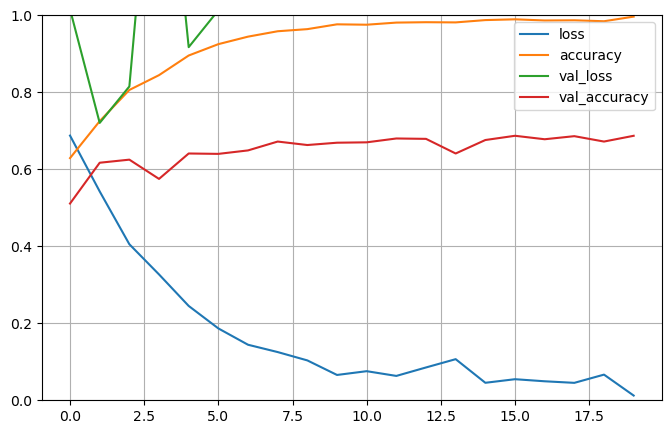

In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [ ]:
model.save("cats_and_dogs_small_1.keras")

In [ ]:
del model
# clear the Keras session to free up resources after saving the model
keras.backend.clear_session()

In [12]:
# use imported layers
data_augmentation = keras.Sequential([
    layers.Rescaling(1./255),                    # replaces rescale=1./255
    layers.RandomFlip("horizontal"),             # horizontal_flip=True
    layers.RandomRotation(40/360),               # rotation_range=40  → factor of 2π
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2),  # shift_range=0.2
    layers.RandomZoom(0.2),
    # fill_mode='nearest' is the default in most of these layers
])

train_generator = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(150, 150),
    batch_size=32,
    label_mode="binary",
).map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

validation_generator = keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(150, 150),
    batch_size=32,
    label_mode="binary",
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
